In [ ]:
from pathlib import Path
import os, sys

# Ensure a common Results/ folder next to Experiments/
cwd = Path.cwd().resolve()
if cwd.name == "Experiments" and (cwd.parent / "Helpers").exists():
    PROJECT_ROOT = cwd.parent
elif (cwd / "Helpers").exists():
    PROJECT_ROOT = cwd
elif (cwd / "MICRO-489_SMLM_tracking" / "Helpers").exists():
    PROJECT_ROOT = cwd / "MICRO-489_SMLM_tracking"
else:
    raise RuntimeError(f"Could not find project root from {cwd}")

OUT_DIR = PROJECT_ROOT / "Results"
OUT_DIR.mkdir(parents=True, exist_ok=True)
print(f"Results directory: {OUT_DIR}")

# Assignment experiment
## **Goal**: compare Local NN, Global NN and hungarian algorithms
1) peak-to-peak assignment
2) traj-to-traj assignment

In [29]:
%cd ..
from Helpers.helpersGeneration import *
from Helpers.helpersTracking import *
from Helpers.helpersStatistics import *
from Helpers.helpersAssignment import *

c:\Users\armel\OneDrive - epfl.ch\MA2\SMLM


In [30]:
nparticles=27
nframes=40
nposframe=5
D_list = [
    (0.10, 0.30),  
    (0.50, 0.10),  
    (1.50, 0.15),  
    (3.50, 0.10),
    (4.00, 0.15),
    (5.00, 0.20)
]
intensity_mean=700
intensity_std=300

In [31]:
# experiment: strong filamentous diffusion at 30 degrees
trajectories_aniso = simulate_brownian_motion(
    nparticles=nparticles,
    nframes=nframes,
    nposframe=nposframe,
    D_list=D_list,
    dt=1.0,
    anisotropy_ratio_range=(1.0, 1.0), # isotropic diffusion
    theta_range=(np.deg2rad(0), np.deg2rad(0)),
    frame_size=(128, 128), # renommer frame size
    intensity_mean=700,
    intensity_std=300
)

image_props = {
    "particle_intensity": [700, 300], # backup is particle intensity is None
    "background_intensity": [100, 30],
    "poisson_noise": 100,
    "output_size": 128,
    "upsampling_factor": 5,
    "resolution": 100e-9,
    "trajectory_unit": -1,   # trajectories already in pixels
    "invert_y": True,
}

video_aniso= trajectories_to_global_video(
    trajectories_aniso, # still at subframe resolution
    nframes=nframes,
    nPosPerFrame=nposframe,
    image_props=image_props,
)

In [32]:
trajectories_GT = create_GT_trajectories(trajectories_aniso, nposframe)
frames = video_aniso.astype(np.float32)

In [33]:
_, cost_peak2peak_local, assignment_localization_local, cost_traj2traj_local = track(
    frames,
    trajectories_GT,
    detection_threshold=intensity_mean - 1.0 * intensity_std,
    max_distance=2,
    min_length=10,
    r_squared_threshold=0.7,
    algo_peak2peak="local_nn",
    algo_traj2traj="local_nn",
    cost_function=None,
    verbose_loc=False,
    visualization_loc=False,
    verbose_assignment=False,
)

[Frame 0] Fitted center for peak at (21, 93): (20.97, 92.84), amplitude 958.55, sigma 1.31
[Frame 0] Fitted center for peak at (40, 85): (39.29, 85.00), amplitude 908.71, sigma 1.40
[Frame 0] Fitted center for peak at (99, 96): (98.71, 95.95), amplitude 887.83, sigma 1.32
[Frame 0] Fitted center for peak at (102, 111): (101.58, 110.64), amplitude 871.74, sigma 1.83
[Frame 0] Fitted center for peak at (53, 26): (53.66, 25.66), amplitude 816.55, sigma 1.67
[Frame 0] Fitted center for peak at (109, 36): (109.13, 36.30), amplitude 838.20, sigma 1.91
[Frame 0] Fitted center for peak at (45, 92): (44.20, 91.76), amplitude 696.80, sigma 1.77
[Frame 0] Fitted center for peak at (46, 62): (45.71, 62.30), amplitude 592.88, sigma 1.71
[Frame 0] Fitted center for peak at (65, 55): (65.24, 55.07), amplitude 578.39, sigma 1.58
[Frame 0] Fitted center for peak at (23, 35): (22.76, 35.24), amplitude 650.06, sigma 2.28
[Frame 0] Fitted center for peak at (46, 86): (45.38, 85.99), amplitude 438.11, sigm

In [34]:
_, cost_peak2peak_global, assignment_localization_global, cost_traj2traj_global = track(
    frames,
    trajectories_GT,
    detection_threshold=intensity_mean - 1.0 * intensity_std,
    max_distance=2,
    min_length=10,
    r_squared_threshold=0.7,
    algo_peak2peak="global_nn",
    algo_traj2traj="global_nn",
    cost_function=None,
    verbose_loc=False,
    visualization_loc=False,
    verbose_assignment=False,
)

[Frame 0] Fitted center for peak at (21, 93): (20.97, 92.84), amplitude 958.55, sigma 1.31
[Frame 0] Fitted center for peak at (40, 85): (39.29, 85.00), amplitude 908.71, sigma 1.40
[Frame 0] Fitted center for peak at (99, 96): (98.71, 95.95), amplitude 887.83, sigma 1.32
[Frame 0] Fitted center for peak at (102, 111): (101.58, 110.64), amplitude 871.74, sigma 1.83
[Frame 0] Fitted center for peak at (53, 26): (53.66, 25.66), amplitude 816.55, sigma 1.67
[Frame 0] Fitted center for peak at (109, 36): (109.13, 36.30), amplitude 838.20, sigma 1.91
[Frame 0] Fitted center for peak at (45, 92): (44.20, 91.76), amplitude 696.80, sigma 1.77
[Frame 0] Fitted center for peak at (46, 62): (45.71, 62.30), amplitude 592.88, sigma 1.71
[Frame 0] Fitted center for peak at (65, 55): (65.24, 55.07), amplitude 578.39, sigma 1.58
[Frame 0] Fitted center for peak at (23, 35): (22.76, 35.24), amplitude 650.06, sigma 2.28
[Frame 0] Fitted center for peak at (46, 86): (45.38, 85.99), amplitude 438.11, sigm

In [35]:
_, cost_peak2peak_hungarian, assignment_localization_hungarian, cost_traj2traj_hungarian = track(
    frames,
    trajectories_GT,
    detection_threshold=intensity_mean - 1.0 * intensity_std,
    max_distance=2,
    min_length=10,
    r_squared_threshold=0.7,
    algo_peak2peak="hungarian",
    algo_traj2traj="hungarian",
    cost_function=None,
    verbose_loc=False,
    visualization_loc=False,
    verbose_assignment=False,
)

[Frame 0] Fitted center for peak at (21, 93): (20.97, 92.84), amplitude 958.55, sigma 1.31
[Frame 0] Fitted center for peak at (40, 85): (39.29, 85.00), amplitude 908.71, sigma 1.40
[Frame 0] Fitted center for peak at (99, 96): (98.71, 95.95), amplitude 887.83, sigma 1.32
[Frame 0] Fitted center for peak at (102, 111): (101.58, 110.64), amplitude 871.74, sigma 1.83
[Frame 0] Fitted center for peak at (53, 26): (53.66, 25.66), amplitude 816.55, sigma 1.67
[Frame 0] Fitted center for peak at (109, 36): (109.13, 36.30), amplitude 838.20, sigma 1.91
[Frame 0] Fitted center for peak at (45, 92): (44.20, 91.76), amplitude 696.80, sigma 1.77
[Frame 0] Fitted center for peak at (46, 62): (45.71, 62.30), amplitude 592.88, sigma 1.71
[Frame 0] Fitted center for peak at (65, 55): (65.24, 55.07), amplitude 578.39, sigma 1.58
[Frame 0] Fitted center for peak at (23, 35): (22.76, 35.24), amplitude 650.06, sigma 2.28
[Frame 0] Fitted center for peak at (46, 86): (45.38, 85.99), amplitude 438.11, sigm

In [36]:
print(len(cost_peak2peak_hungarian))

39


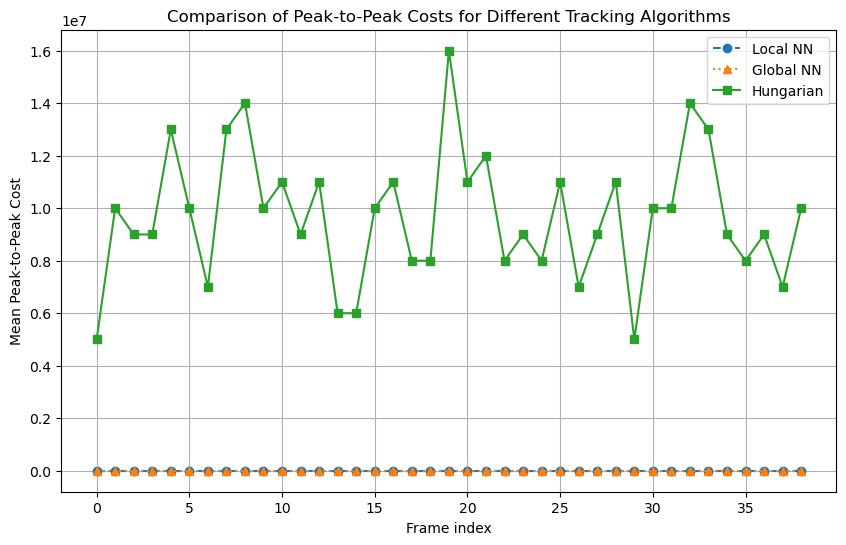

In [37]:
# for the peak2peak costs (of size nframes-1 because they are between consecutive frames), we can compute the mean cost across all frames
mean_cost_peak2peak_local = np.mean(cost_peak2peak_local)
mean_cost_peak2peak_global = np.mean(cost_peak2peak_global)
mean_cost_peak2peak_hungarian = np.mean(cost_peak2peak_hungarian)

# plot the comparison of the costs for the three algorithms
plt.figure(figsize=(10, 6))
plt.plot(cost_peak2peak_local, label='Local NN', linestyle='--', marker='o')
plt.plot(cost_peak2peak_global, label='Global NN', linestyle=':', marker='^')
plt.plot(cost_peak2peak_hungarian, label='Hungarian', linestyle='-', marker='s')
plt.xlabel('Frame index')
plt.ylabel('Mean Peak-to-Peak Cost')
plt.title('Comparison of Peak-to-Peak Costs for Different Tracking Algorithms')
plt.legend()
plt.grid()
plt.show()


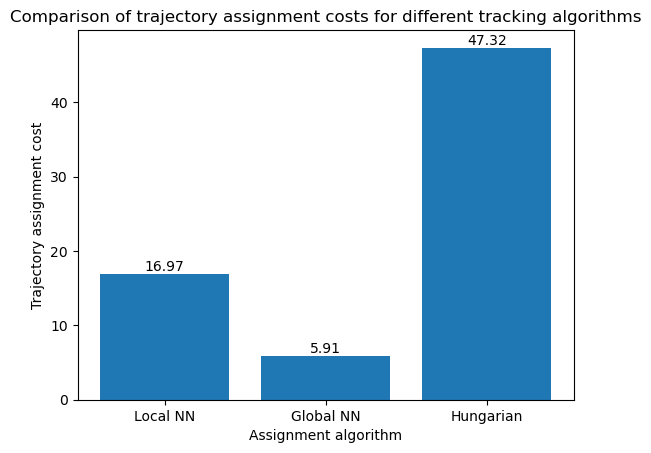

In [38]:
bars = plt.bar(
    x=['Local NN', 'Global NN', 'Hungarian'],
    height=[cost_traj2traj_local, cost_traj2traj_global, cost_traj2traj_hungarian]
)

plt.xlabel('Assignment algorithm')
plt.ylabel('Trajectory assignment cost')
plt.title('Comparison of trajectory assignment costs for different tracking algorithms')

# Add value labels
for bar in bars:
    height = bar.get_height()
    plt.text(
        bar.get_x() + bar.get_width() / 2,
        height,
        f'{height:.2f}',
        ha='center',
        va='bottom'
    )

plt.show()

-> false because the assignment is probably wrong... must check with msd matching (of GT)